# Challenge 1: datos y análisis exploratorio

Tu primera responsabilidad es preparar una fuente de datos confiable para el proyecto de clasificación de vinos.

**Entrada:** `data/raw/wine.csv`  
**Salidas:** `data/processed/train.csv`, `data/processed/test.csv` y `artifacts/data_contract.json`

> El conjunto de test se crea aquí, pero no debe explorarse ni utilizarse después del split.

## Objetivos

- cargar y validar datos externos;
- identificar problemas básicos de calidad;
- crear un split reproducible y estratificado;
- realizar EDA únicamente sobre entrenamiento;
- guardar datos y metadatos para la siguiente etapa.

In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

np.random.seed(42)
plt.rcParams["figure.figsize"] = (7, 4)

In [2]:
from pathlib import Path

PROJECT_DIR = Path.cwd()
RAW_DATA_DIR = PROJECT_DIR / "data" / "raw"
PROCESSED_DATA_DIR = PROJECT_DIR / "data" / "processed"
ARTIFACTS_DIR = PROJECT_DIR / "artifacts"
REPORTS_DIR = PROJECT_DIR / "reports"

for directory in (PROCESSED_DATA_DIR, ARTIFACTS_DIR, REPORTS_DIR):
    directory.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42

## 1. Carga y profiling

In [3]:
DATA_PATH = RAW_DATA_DIR / "wine.csv"

df = pd.read_csv(DATA_PATH)
df.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


In [4]:
print("Forma del dataset:", df.shape)
print()
print("Tipos de datos:")
print(df.dtypes)
print()
print("Valores nulos por columna:")
print(df.isnull().sum())
print()
print("Filas duplicadas:", df.duplicated().sum())
print()
print("Distribución de la variable target:")
print(df["target"].value_counts())
print()
print("Proporción de la variable target:")
print(df["target"].value_counts(normalize=True).round(3))
print()
print("Estadísticas descriptivas:")
df.describe().T

Forma del dataset: (178, 14)

Tipos de datos:
alcohol                         float64
malic_acid                      float64
ash                             float64
alcalinity_of_ash               float64
magnesium                       float64
total_phenols                   float64
flavanoids                      float64
nonflavanoid_phenols            float64
proanthocyanins                 float64
color_intensity                 float64
hue                             float64
od280/od315_of_diluted_wines    float64
proline                         float64
target                            int64
dtype: object

Valores nulos por columna:
alcohol                         0
malic_acid                      0
ash                             0
alcalinity_of_ash               0
magnesium                       0
total_phenols                   0
flavanoids                      0
nonflavanoid_phenols            0
proanthocyanins                 0
color_intensity                 0
hue         

,count,mean,std,min,25%,50%,75%,max
alcohol,178.0,13.000618,0.811827,11.03,12.3625,13.050,13.6775,14.83
malic_acid,178.0,2.336348,1.117146,0.74,1.6025,1.865,3.0825,5.80
ash,178.0,2.366517,0.274344,1.36,2.2100,2.360,2.5575,3.23
alcalinity_of_ash,178.0,19.494944,3.339564,10.60,17.2000,19.500,21.5000,30.00
magnesium,178.0,99.741573,14.282484,70.00,88.0000,98.000,107.0000,162.00
total_phenols,178.0,2.295112,0.625851,0.98,1.7425,2.355,2.8000,3.88
flavanoids,178.0,2.029270,0.998859,0.34,1.2050,2.135,2.8750,5.08
nonflavanoid_phenols,178.0,0.361854,0.124453,0.13,0.2700,0.340,0.4375,0.66
proanthocyanins,178.0,1.590899,0.572359,0.41,1.2500,1.555,1.9500,3.58
color_intensity,178.0,5.058090,2.318286,1.28,3.2200,4.690,6.2000,13.00


**Conclusión de calidad:**

> El dataset contiene 178 registros y 14 columnas (13 variables químicas numéricas + `target`), sin valores nulos ni filas duplicadas. La variable objetivo `target` tiene 3 clases (0, 1, 2) con un desbalance moderado (71, 59 y 48 observaciones respectivamente), por lo que se decidió usar `stratify=df["target"]` en el split para preservar esta proporción tanto en entrenamiento como en prueba. Las variables numéricas presentan escalas muy distintas (por ejemplo `proline` en cientos vs. `hue` en unidades), lo cual deberá tenerse en cuenta al escalar los datos en etapas posteriores de modelado.

## 2. Split train/test

In [5]:
FEATURE_COLUMNS = [c for c in df.columns if c != "target"]
TARGET_COLUMN = "target"
TEST_SIZE = 0.2

train_df, test_df = train_test_split(
    df,
    test_size=TEST_SIZE,
    stratify=df[TARGET_COLUMN],
    random_state=RANDOM_STATE,
)

train_df.shape, test_df.shape

((142, 14), (36, 14))

In [6]:
# Verificación del split
assert len(train_df) + len(test_df) == len(df)
assert set(train_df.index).isdisjoint(set(test_df.index))
print("Train:", train_df.shape)
print("Test:", test_df.shape)

Train: (142, 14)
Test: (36, 14)


## 3. EDA sobre entrenamiento

Incluye:

- distribución de clases;
- distribuciones o boxplots de variables relevantes;
- correlaciones;
- tres hallazgos que puedan influir en el modelado.

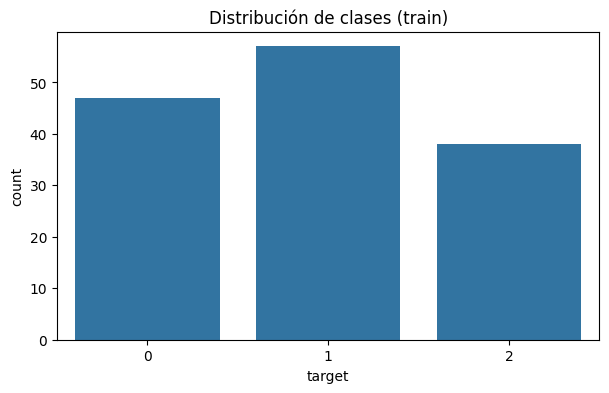

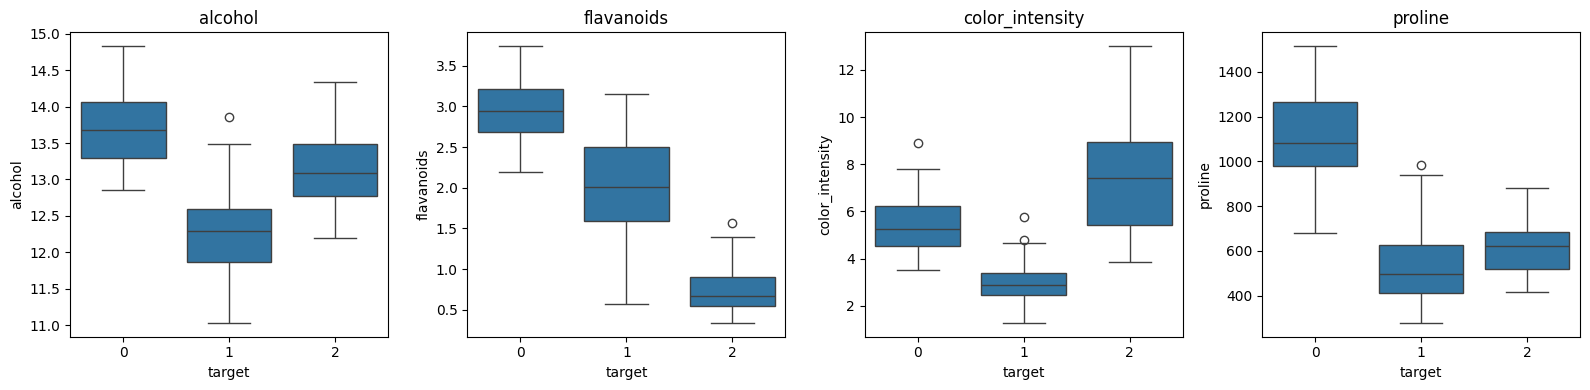

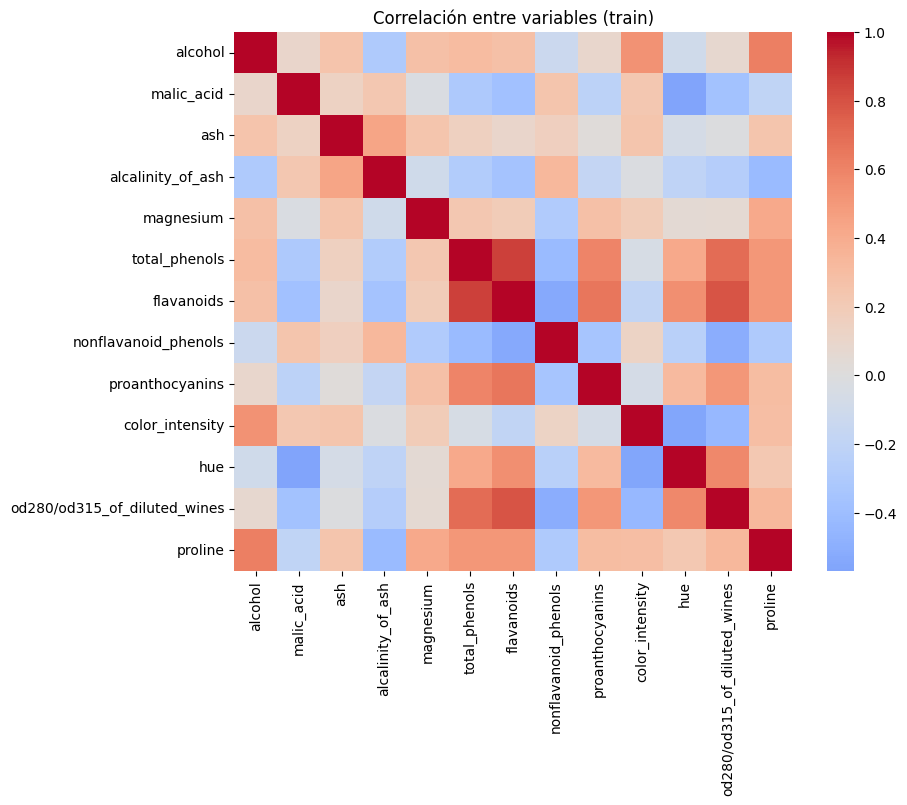

In [7]:
# 1. Distribución de clases en entrenamiento
fig, ax = plt.subplots()
sns.countplot(x="target", data=train_df, ax=ax)
ax.set_title("Distribución de clases (train)")
plt.show()

# 2. Boxplots de variables relevantes por clase
relevant_vars = ["alcohol", "flavanoids", "color_intensity", "proline"]
fig, axes = plt.subplots(1, len(relevant_vars), figsize=(16, 4))
for ax, var in zip(axes, relevant_vars):
    sns.boxplot(x="target", y=var, data=train_df, ax=ax)
    ax.set_title(var)
plt.tight_layout()
plt.show()

# 3. Matriz de correlación (solo variables numéricas de entrada)
fig, ax = plt.subplots(figsize=(9, 7))
corr = train_df[FEATURE_COLUMNS].corr()
sns.heatmap(corr, cmap="coolwarm", center=0, annot=False, ax=ax)
ax.set_title("Correlación entre variables (train)")
plt.show()

**Hallazgos:**

1. Las clases están moderadamente desbalanceadas (la clase 1 es la más numerosa y la clase 2 la más pequeña), algo a considerar al elegir métricas de evaluación (p. ej. F1 macro en vez de accuracy).
2. Variables como `flavanoids`, `color_intensity` y `proline` muestran distribuciones claramente diferenciadas entre clases, lo que sugiere que serán buenas variables predictoras para el modelo.
3. Existen correlaciones fuertes entre algunas variables (por ejemplo `flavanoids` con `total_phenols` y `od280/od315_of_diluted_wines`), lo que indica posible multicolinealidad a tener en cuenta en modelos lineales.

## 4. Persistencia de datos y contrato

In [8]:
train_out = train_df.reset_index(drop=True)
test_out = test_df.reset_index(drop=True)

train_out.to_csv(PROCESSED_DATA_DIR / "train.csv", index=False)
test_out.to_csv(PROCESSED_DATA_DIR / "test.csv", index=False)

data_contract = {
    "target": TARGET_COLUMN,
    "features": FEATURE_COLUMNS,
    "random_state": RANDOM_STATE,
    "test_size": TEST_SIZE,
}

with open(ARTIFACTS_DIR / "data_contract.json", "w", encoding="utf-8") as f:
    json.dump(data_contract, f, indent=2, ensure_ascii=False)

data_contract

{'target': 'target',
 'features': ['alcohol',
  'malic_acid',
  'ash',
  'alcalinity_of_ash',
  'magnesium',
  'total_phenols',
  'flavanoids',
  'nonflavanoid_phenols',
  'proanthocyanins',
  'color_intensity',
  'hue',
  'od280/od315_of_diluted_wines',
  'proline'],
 'random_state': 42,
 'test_size': 0.2}

In [9]:
# Verificación de entrega
assert (PROCESSED_DATA_DIR / "train.csv").exists()
assert (PROCESSED_DATA_DIR / "test.csv").exists()
assert (ARTIFACTS_DIR / "data_contract.json").exists()
print("Challenge 1 completado.")

Challenge 1 completado.


## Checklist

- [x] Cargué el CSV desde `data/raw`.
- [x] Revisé calidad y distribución de la clase.
- [x] Realicé un split estratificado.
- [x] No exploré el conjunto de test.
- [x] Guardé los tres artefactos requeridos.